# Waist mechanism - complete Dynamics

![Screenshot from 2026-03-02 19-24-09.png](<attachment:Screenshot from 2026-03-02 19-24-09.png>)
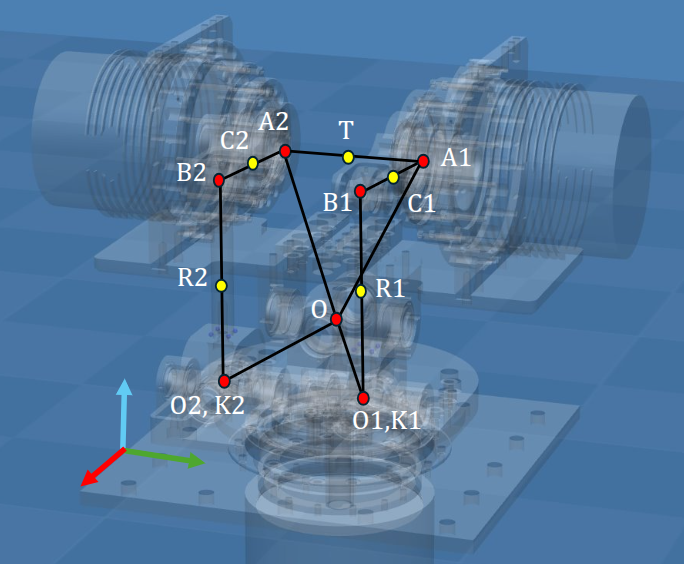

In [1]:

import sympy as sp
import numpy as np
import sympy.physics.mechanics as me 
me.init_vprinting()

from scipy.optimize import fsolve
from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
plt.rcParams['animation.embed_limit'] = 150
from IPython.display import HTML

## Symbols

In [2]:

t = me.dynamicsymbols._t

N, S, B, U1, U2, L1, L2 = sp.symbols('N, S, B, U_1, U_2, L_1, L_2', cls=me.ReferenceFrame)
O, P, T, C1, C2, R1, R2 = sp.symbols('O, P, T, C_1, C_2, R_1 , R_2', cls=me.Point)                           # CoM points for the bodies
A1, A2, B1, B2, K1, K2, O1, O2 = sp.symbols('A_1, A_2, B_1, B_2, K_1, K_2, O_1, O_2', cls=me.Point)         # points for constraints / loop closure
q1, q2, q3, q4, q5, q6, q7, q8 = me.dynamicsymbols('q1:9')

ls, lc, lr, lf, lt1, lt2 = sp.symbols('l_s, l_c, l_r, l_f l_t1 l_t2' , positive="True")
m_s, m_t, m_c, m_r, g = sp.symbols('m_s, m_t, m_c, m_r, g', positive="True")

I_S_So = me.inertia(S, 1, 1, 1)
I_B_Bo = me.inertia(B, 1, 1, 1)
I_U1_U1o = me.inertia(U1, 1, 1, 1)
I_U2_U2o = me.inertia(U2, 1, 1, 1)
I_L1_L1o = me.inertia(L1, 1, 1, 1)
I_L2_L2o = me.inertia(L2, 1, 1, 1)

T1, T2, T3 = me.dynamicsymbols('T_torso T_joint18 T_joint19 ')
p = sp.Matrix([ls, lc, lr, lf, lt1, lt2, m_s, m_t, m_c, m_r, g])


## Generalised coordinates

In [3]:
u1, u2, u3, u4, u5, u6, u7, u8 = me.dynamicsymbols('u1:9')

q = sp.Matrix([q1, q2])
q_r = sp.Matrix([q3, q4, q5, q6, q7, q8])
q_N = q.col_join(q_r)

u = sp.Matrix([u1, u2])
u_r = sp.Matrix([u3, u4, u5, u6, u7, u8])
u_N = u.col_join(u_r)

qdot_N = q_N.diff(t)
q_r_dot = q_r.diff(t)
q_r_ddot = q_r_dot.diff(t)

udot = u.diff(t)
u_r_dot = u_r.diff(t)

u_zero = {u: 0 for u in u}
u_r_zero = {u: 0 for u in u_r}
udot_zero = {u:0 for u in udot}

q, q_r, q_N, u, u_r, u_N, udot, u_r_dot

⎛            ⎡q₁⎤              ⎡u₁⎤            ⎞
⎜            ⎢  ⎥              ⎢  ⎥            ⎟
⎜      ⎡q₃⎤  ⎢q₂⎥        ⎡u₃⎤  ⎢u₂⎥        ⎡u₃̇⎤⎟
⎜      ⎢  ⎥  ⎢  ⎥        ⎢  ⎥  ⎢  ⎥        ⎢  ⎥⎟
⎜      ⎢q₄⎥  ⎢q₃⎥        ⎢u₄⎥  ⎢u₃⎥        ⎢u₄̇⎥⎟
⎜      ⎢  ⎥  ⎢  ⎥        ⎢  ⎥  ⎢  ⎥        ⎢  ⎥⎟
⎜⎡q₁⎤  ⎢q₅⎥  ⎢q₄⎥  ⎡u₁⎤  ⎢u₅⎥  ⎢u₄⎥  ⎡u₁̇⎤  ⎢u₅̇⎥⎟
⎜⎢  ⎥, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥⎟
⎜⎣q₂⎦  ⎢q₆⎥  ⎢q₅⎥  ⎣u₂⎦  ⎢u₆⎥  ⎢u₅⎥  ⎣u₂̇⎦  ⎢u₆̇⎥⎟
⎜      ⎢  ⎥  ⎢  ⎥        ⎢  ⎥  ⎢  ⎥        ⎢  ⎥⎟
⎜      ⎢q₇⎥  ⎢q₆⎥        ⎢u₇⎥  ⎢u₆⎥        ⎢u₇̇⎥⎟
⎜      ⎢  ⎥  ⎢  ⎥        ⎢  ⎥  ⎢  ⎥        ⎢  ⎥⎟
⎜      ⎣q₈⎦  ⎢q₇⎥        ⎣u₈⎦  ⎢u₇⎥        ⎣u₈̇⎦⎟
⎜            ⎢  ⎥              ⎢  ⎥            ⎟
⎝            ⎣q₈⎦              ⎣u₈⎦            ⎠

## Orientations

In [4]:
S.orient_axis(N, q3, N.x)
B.orient_axis(S, q4, S.y)
U1.orient_axis(B, q1, B.y)
U2.orient_axis(B, q2, B.y)
L1.orient_space_fixed(U1, (q5, q6, 0), 'XYZ')
L2.orient_space_fixed(U2, (q7, q8, 0), 'XYZ')

O1.set_pos(O, lc*N.x + ls/2*N.y - lf*N.z)
O2.set_pos(O, lc*N.x - ls/2*N.y - lf*N.z)

P.set_pos(O, me.Vector(0))
T.set_pos(P, lt1*B.x + (lr - lf + lt2)*B.z)

A1.set_pos(T, -lt1*B.x + ls/2*B.y - lt2*B.z)
C1.set_pos(A1, lc/2*U1.x)
B1.set_pos(C1, lc/2*U1.x)
R1.set_pos(B1,- lr/2*L1.z)
K1.set_pos(R1,- lr/2*L1.z)

A2.set_pos(T, -lt1*B.x - ls/2*B.y - lt2*B.z)
C2.set_pos(A2, lc/2*U2.x)
B2.set_pos(C2, lc/2*U2.x)
R2.set_pos(B2,- lr/2*L2.z)
K2.set_pos(R2,- lr/2*L2.z)

## Holonomic constraints

In [5]:
# loop closure equations

rod_constraint1 = B1.pos_from(O) - O1.pos_from(O)
rod_constraint2 = B2.pos_from(O) - O2.pos_from(O)
loop_closure1 = K1.pos_from(O) - O1.pos_from(O)
loop_closure2 = K2.pos_from(O) - O2.pos_from(O)


In [6]:
# Holonomic constraints

fh = sp.Matrix([
    rod_constraint1.dot(rod_constraint1) - lr**2,
    rod_constraint2.dot(rod_constraint2) - lr**2,
    loop_closure1.dot(N.y) - 0,
    loop_closure2.dot(N.y) - 0,
    loop_closure1.dot(N.z) - 0,
    loop_closure2.dot(N.z) - 0,
    ])

fh = fh.applyfunc(lambda i: sp.simplify(sp.trigsimp(i)))

In [7]:
fh

⎡                                                                              ↪
⎢       2                     2                                                ↪
⎢- 2⋅l_c ⋅cos(q₁ + q₄) + 2⋅l_c  - 2⋅l_c⋅l_f⋅sin(q₁ + q₄)⋅cos(q₃) + 2⋅l_c⋅l_f⋅s ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢       2                     2                                                ↪
⎢- 2⋅l_c ⋅cos(q₂ + q₄) + 2⋅l_c  - 2⋅l_c⋅l_f⋅sin(q₂ + q₄)⋅cos(q₃) + 2⋅l_c⋅l_f⋅s ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                           

## Kinematic differential equations

In [8]:
fk = sp.Matrix([
    q1.diff(t) - u1,
    q2.diff(t) - u2,
    q3.diff(t) - u3,
    q4.diff(t) - u4,
    q5.diff(t) - u5,
    q6.diff(t) - u6,
    q7.diff(t) - u7,
    q8.diff(t) - u8,    
])

qdot_N_zero = {i: 0 for i in qdot_N}

Mk = fk.jacobian(qdot_N)
gk = fk.xreplace(qdot_N_zero)
qdot_N_sol = -Mk.LUsolve(gk)

qdot_N_replace = dict((zip(qdot_N, qdot_N_sol)))
qdot_N_replace

In [9]:
Mk, -gk, qdot_N

⎛⎡1  0  0  0  0  0  0  0⎤  ⎡u₁⎤  ⎡q₁̇⎤⎞
⎜⎢                      ⎥  ⎢  ⎥  ⎢  ⎥⎟
⎜⎢0  1  0  0  0  0  0  0⎥  ⎢u₂⎥  ⎢q₂̇⎥⎟
⎜⎢                      ⎥  ⎢  ⎥  ⎢  ⎥⎟
⎜⎢0  0  1  0  0  0  0  0⎥  ⎢u₃⎥  ⎢q₃̇⎥⎟
⎜⎢                      ⎥  ⎢  ⎥  ⎢  ⎥⎟
⎜⎢0  0  0  1  0  0  0  0⎥  ⎢u₄⎥  ⎢q₄̇⎥⎟
⎜⎢                      ⎥, ⎢  ⎥, ⎢  ⎥⎟
⎜⎢0  0  0  0  1  0  0  0⎥  ⎢u₅⎥  ⎢q₅̇⎥⎟
⎜⎢                      ⎥  ⎢  ⎥  ⎢  ⎥⎟
⎜⎢0  0  0  0  0  1  0  0⎥  ⎢u₆⎥  ⎢q₆̇⎥⎟
⎜⎢                      ⎥  ⎢  ⎥  ⎢  ⎥⎟
⎜⎢0  0  0  0  0  0  1  0⎥  ⎢u₇⎥  ⎢q₇̇⎥⎟
⎜⎢                      ⎥  ⎢  ⎥  ⎢  ⎥⎟
⎝⎣0  0  0  0  0  0  0  1⎦  ⎣u₈⎦  ⎣q₈̇⎦⎠

In [10]:
fh_d = fh.diff(t).xreplace(qdot_N_replace)


In [11]:
fh_d

⎡                                                                              ↪
⎢     2                                                                        ↪
⎢2⋅l_c ⋅(u₁ + u₄)⋅sin(q₁ + q₄) - 2⋅l_c⋅l_f⋅(u₁ + u₄)⋅cos(q₁ + q₄)⋅cos(q₃) + 2⋅ ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢     2                                                                        ↪
⎢2⋅l_c ⋅(u₂ + u₄)⋅sin(q₂ + q₄) - 2⋅l_c⋅l_f⋅(u₂ + u₄)⋅cos(q₂ + q₄)⋅cos(q₃) + 2⋅ ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                           

In [12]:
me.find_dynamicsymbols(fh_d)

In [13]:

Mh_d = fh_d.jacobian(u_r)
gh_d = fh_d.xreplace(u_r_zero)

me.find_dynamicsymbols(fh.diff(t)), me.find_dynamicsymbols(fh_d), me.find_dynamicsymbols(gh_d)

In [14]:
u_r_sol = -Mh_d.LUsolve(gh_d)

u_r_replace = dict(zip(u_r, u_r_sol))

me.find_dynamicsymbols(u_r_sol)

In [15]:
u_r_dot_sol = u_r_sol.diff(t).xreplace(qdot_N_replace).xreplace(u_r_replace)

In [16]:
me.find_dynamicsymbols(u_r_dot_sol)

In [17]:
q_r_ddot_replace = dict(zip(q_r_ddot, u_r_dot_sol))
q_r_ddot

⎡q₃̈⎤
⎢  ⎥
⎢q₄̈⎥
⎢  ⎥
⎢q₅̈⎥
⎢  ⎥
⎢q₆̈⎥
⎢  ⎥
⎢q₇̈⎥
⎢  ⎥
⎣q₈̈⎦

## Velocities and Acceleration

In [18]:
S.set_ang_vel(N, u_r_replace[u3]*S.x)
B.set_ang_vel(S, u_r_replace[u4]*B.y)
U1.set_ang_vel(B, u1*U1.y)
U2.set_ang_vel(B, u2*U2.y)

In [19]:
O.set_vel(N,0)
v_P_N  = P.v2pt_theory(O, N, S)
v_T_N  = T.v2pt_theory(O, N, B)
v_C1_N = C1.v2pt_theory(O, N, U1)
v_C2_N = C2.v2pt_theory(O, N, U2)
v_R1_N = R1.v2pt_theory(O, N, L1).xreplace(qdot_N_replace).xreplace(u_r_replace)
v_R2_N = R2.v2pt_theory(O, N, L2).xreplace(qdot_N_replace).xreplace(u_r_replace)

w_S_N  = S.ang_vel_in(N)
w_B_N  = B.ang_vel_in(N)
w_U1_N = U1.ang_vel_in(N)
w_U2_N = U2.ang_vel_in(N)
w_L1_N = L1.ang_vel_in(N).xreplace(qdot_N_replace).xreplace(u_r_replace)
w_L2_N = L2.ang_vel_in(N).xreplace(qdot_N_replace).xreplace(u_r_replace)


In [20]:

wd_S_N  = S.ang_acc_in(N).xreplace(qdot_N_replace).xreplace(u_r_replace)
wd_B_N  = B.ang_acc_in(N).xreplace(qdot_N_replace).xreplace(u_r_replace)
wd_U1_N = U1.ang_acc_in(N).xreplace(qdot_N_replace).xreplace(u_r_replace)
wd_U2_N = U2.ang_acc_in(N).xreplace(qdot_N_replace).xreplace(u_r_replace)
wd_L1_N = L1.ang_acc_in(N).xreplace(qdot_N_replace).xreplace(q_r_ddot_replace).xreplace(u_r_replace)
wd_L2_N = L2.ang_acc_in(N).xreplace(qdot_N_replace).xreplace(q_r_ddot_replace).xreplace(u_r_replace)

In [21]:

a_P_N  = P.acc(N).xreplace(qdot_N_replace).xreplace(u_r_replace)
a_T_N  = T.acc(N).xreplace(qdot_N_replace).xreplace(u_r_replace)
a_C1_N = C1.acc(N).xreplace(qdot_N_replace).xreplace(u_r_replace)
a_C2_N = C2.acc(N).xreplace(qdot_N_replace).xreplace(u_r_replace)
a_R1_N = R1.acc(N).xreplace(qdot_N_replace).xreplace(q_r_ddot_replace).xreplace(u_r_replace)
a_R2_N = R2.acc(N).xreplace(qdot_N_replace).xreplace(q_r_ddot_replace).xreplace(u_r_replace)

In [22]:
# me.find_dynamicsymbols(v_R2_N, reference_frame=N) | me.find_dynamicsymbols(a_R2_N, reference_frame=N) | me.find_dynamicsymbols(w_L2_N, reference_frame=N)| me.find_dynamicsymbols(wd_L2_N, reference_frame=N)

## Generalised Active and Inertial forces

In [23]:
# Forces

R_P  = -m_s*g*N.z
R_T  = -m_t*g*N.z
R_C1 = -m_c*g*N.z 
R_C2 = -m_c*g*N.z
R_R1 = -m_r*g*N.z 
R_R2 = -m_r*g*N.z

# Torques

# T_B = -T2*B.y -T3*B.y
# T_U1 = T2*U1.y
# T_U2 = T3*U2.y
# T_L1 = me.Vector(0)
# T_L2 = me.Vector(0)

T_S  = me.Vector(0)
T_B  = me.Vector(0)
T_U1 = me.Vector(0)
T_U2 = me.Vector(0)
T_L1 = me.Vector(0)
T_L2 = me.Vector(0)

In [24]:
ang_vel = [w_B_N, w_U1_N, w_L1_N, w_U2_N, w_L2_N]
lin_vel = [v_T_N, v_C1_N, v_R1_N, v_C2_N, v_R2_N]
 
ang_acc = [wd_B_N, wd_U1_N, wd_L1_N, wd_U2_N, wd_L2_N]
lin_acc = [a_T_N, a_C1_N, a_R1_N, a_C2_N, a_R2_N]

masses = [m_t, m_c, m_r ,m_c, m_r]
forces = [R_T, R_C1, R_R1, R_C2, R_R2]

inertias = [I_B_Bo, I_U1_U1o, I_L1_L1o, I_U2_U2o, I_L2_L2o]
torques = [T_B, T_U1, T_L1, T_U2, T_L2]

Fr_bar = []
Frs_bar = []

for ur in [u1, u2]:

    Fr = 0
    Frs = 0

    for vi, ai, Ri, mi in zip(lin_vel, lin_acc, forces, masses):
        vr = vi.diff(ur, N)
        Fr += vr.dot(Ri)
        Rs = -mi*ai
        Frs += vr.dot(Rs)

    for wi, aai, Ti, Ii in zip(ang_vel, ang_acc, torques, inertias):
        wr = wi.diff(ur, N)
        Fr += wr.dot(Ti)
        Ts = -(aai.dot(Ii) +
               me.cross(wi, Ii).dot(wi))
        Frs += wr.dot(Ts)

    Fr_bar.append(Fr)
    Frs_bar.append(Frs)

Fr = sp.Matrix(Fr_bar)
Frs = sp.Matrix(Frs_bar)

## Equations of Motion

In [25]:
EOM = Fr + Frs

EOM.free_symbols

## Static torque on the joints

In [56]:

EOM_num = EOM.xreplace(u_zero).xreplace(udot_zero).evalf(n=7).doit()

In [97]:
p_value = {
    g: 9.81,
    lc: 0.095,
    lf: 0.02,
    lr: 0.115,
    ls: 0.08,
    lt1: 0.363,                         # upper body cg x (front)
    lt2: 0.28,                          # upper body cg z 
    m_s: 0.2,
    m_c: 0.2,
    m_r: 0.2,
    m_t: 70.0,                          # upper body mass with payload
    q1: sp.rad(-20.63046792),           #-20.63046792 # 19.3715
    q2: sp.rad(-20.63046792),
    q3: sp.rad(0.0),
    q4: sp.rad(20.0),
    q5: sp.rad(0.0),
    q6: sp.rad(0.0),
    q7: sp.rad(0.0),
    q8: sp.rad(0.0)
}

EOM_val = EOM_num.xreplace(p_value).evalf(n=7).doit()
Ts = [T2, T3]

sp.Eq(sp.Matrix(Ts),-EOM_val)

⎡T_joint18⎤   ⎡146.3411⎤
⎢         ⎥ = ⎢        ⎥
⎣T_joint19⎦   ⎣146.3411⎦

# Inverse Dynamics

### Animation functions

In [29]:
# coordinates = T.pos_from(O).to_matrix(N)
# for point in [O, O2, B2, A2, A1, B1, O1, O]:
#    coordinates = coordinates.row_join(point.pos_from(O).to_matrix(N))
   
# eval_point_coords = sp.lambdify((q_N, p), coordinates)

In [30]:
# import matplotlib.pyplot as plt

# def setup_animation_plot(ts, xs, p):
#     """Robust 3D animation setup with correct scaling and view."""

#     # Initial joint / point coordinates
#     x, y, z = eval_point_coords(xs[0, :4], p)

#     fig = plt.figure(figsize=(7.5, 7.5))
#     ax = fig.add_subplot(111, projection='3d')

#     lines, = ax.plot(
#         z, y, x,
#         linestyle='-',
#         marker='o',
#         color='black',
#         markerfacecolor='red',
#         markersize=8
#     )

#     title_text = ax.set_title(f'Time = {ts[0]:.2f} s')

#     lim = 0.15 
#     ax.set_xlim(-lim, lim)
#     ax.set_ylim(-lim, lim)
#     ax.set_zlim(-0.05, 0.25)

#     ax.set_box_aspect((1, 1, 1))
    
#     ax.view_init(elev=20, azim=45)

#     ax.set_xlabel(r'$x$ [m]')
#     ax.set_ylabel(r'$y$ [m]')
#     ax.set_zlabel(r'$z$ [m]')

#     ax.grid(True)

#     return fig, ax, title_text, lines

In [31]:

# def animate_linkage(ts, xs, p):
#     """Returns an animation object."""

#     # setup the initial figure and axes (your function)
#     fig, ax, title_text, lines = setup_animation_plot(ts, xs, p)

#     # ---- precompute all point coordinates ----
#     coords = np.zeros((len(ts), 3, lines.get_xdata().size))

#     for i, xi in enumerate(xs):
#         coords[i] = eval_point_coords(xi[:4], p)

#     # ---- animation update function ----
#     def update(i):
#         title_text.set_text('Time = {:1.1f} s'.format(ts[i]))
#         lines.set_data(coords[i, 0, :], coords[i, 1, :])
#         lines.set_3d_properties(coords[i, 2, :])
#         return lines, title_text

#     # prevent premature display
#     plt.close(fig)

#     # ---- create animation ----
#     ani = FuncAnimation(
#         fig,
#         update,
#         frames=len(ts),
#         interval=50,
#         blit=False
#     )

#     return ani

### Solution

In [32]:
# p_val = np.array([0.08, 0.075, 0.115, 0.025, 0.0, 0.25, 0.2, 0.2, 5.0, 9.81])
# param_syms = (g, lc, lf, lr, ls, lt1, lt2, m_s, m_c, m_t)
# state_syms = (q1, q2, q3, q4, u1, u2, u1.diff(t), u2.diff(t))

# EOM_func = sp.lambdify(
#     state_syms + param_syms,
#     EOM,
#     modules="numpy"
# )

In [33]:
# tp = 4              
# phi1 = np.deg2rad(0.0)
# phi2 = np.deg2rad(-90.0)            
# time = np.linspace(0, 10, 300)

# a1, b1 = np.deg2rad(15.0), np.deg2rad(0.0)
# a2, b2 = np.deg2rad(15.0), np.deg2rad(0.0)

# q3_values = a1 * np.cos(2*np.pi*time/tp + phi1) + b1
# q4_values = a2 * np.cos(2*np.pi*time/tp + phi2) + b2

# q_r_values = np.column_stack((q3_values, q4_values))
# q_guess = np.array([0.0, 0.0])
# q_values = np.zeros((len(q_r_values), len(q_guess)))

In [34]:

# fh_func = sp.lambdify((q, q_r, p), fh)

# for i, q_r_values_i in enumerate(q_r_values):
#     q_values[i] = fsolve(
#         lambda q, q_r, p: np.squeeze(fh_func(q, q_r, p)),
#         q_guess,
#         args=(q_r_values_i, p_val),
#         xtol=1.49012e-10
#     )


In [35]:
# plt.plot(time,np.degrees(q3_values), label=r'${q}_3$')
# plt.plot(time,np.degrees(q4_values), label=r'${q}_4$')
# plt.legend()

In [36]:
# plt.plot(time,np.degrees(q_values[:,0]), label=r'${q}_1$')
# plt.plot(time,np.degrees(q_values[:,1]), label=r'${q}_2$')
# plt.legend()

In [37]:
# q_all = np.hstack((q_values, q_r_values))

# dt = time[1] - time[0]

# u_values = np.gradient(q_values, dt, axis=0)
# udot_values = np.gradient(u_values, dt, axis=0)


In [38]:
# actuator_torques = EOM_func(
#     q_values[:,0],
#     q_values[:,1],
#     q_r_values[:,0],
#     q_r_values[:,1],
#     u_values[:,0],
#     u_values[:,1],
#     udot_values[:,0],
#     udot_values[:,1],
#     9.81,     # g
#     0.075,    # lc
#     0.025,    # lf
#     0.115,    # lr
#     0.08,     # ls
#     0.0,      # lt1
#     0.15,     # lt2
#     0.2,      # m_s
#     0.2,      # m_c
#     30.0      # m_t
# )

# actuator_torques = np.squeeze(actuator_torques, axis=1).T

In [39]:
# plt.plot(time,actuator_torques[:,0], label=r'$T_{joint18}$')
# plt.plot(time,actuator_torques[:,1], label=r'$T_{joint19}$')
# plt.legend()

### Simulation & Plot

In [40]:
# parameters = np.array([0.08, 0.075, 0.115, 0.025, 0.0, 0.15, 0.2, 0.2, 5.0, 9.81])

# motion = animate_linkage(time, q_all, parameters)
# HTML(motion.to_jshtml())